# Structures and weights

Structural weights by group: the AFDD tiltrotor wing with whirl-flutter stiffness, the XV-15 weight statement
used for calibration, and the geometry and CG build-up. Finite-element checks of the wing box run separately
(`python -m examples.halo_wing_fe`, needs CalculiX).

In [1]:
import sys
import time
import warnings
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. The baseline airframe

In [2]:
# The baseline design: every model at its highest fidelity (about 10 minutes from cold).
from examples.halo_sizing import (HaloAssumptions as RefAssumptions, HaloRequirements as RefRequirements,
                                  soc_emergency_floor, soc_minimum, solve_halo_sizing as solve_reference)
t0 = time.time()
ref = solve_reference()
print(f"baseline design: {ref.mass_takeoff_kg:,.0f} kg = {ref.mass_takeoff_kg / u.lbm:,.0f} lb, "
      f"empty {ref.mass_empty_kg:,.0f} kg, fuel {ref.mass_fuel_kg:,.0f} kg ({(time.time() - t0) / 60:.1f} min)")
check("baseline design closes with every margin satisfied", ref.min_margin > -1e-6)
check("baseline take-off weight 15,179 lb (+- 20)", abs(ref.mass_takeoff_kg / u.lbm - 15179) < 20)

CasADi - 2026-10-06 02:04:40 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


reference: 6,885 kg = 15,179 lb, empty 5,049 kg, fuel 936 kg (9.0 min)
PASS  reference closes with every margin satisfied
PASS  reference take-off weight 15,179 lb (+- 20)


In [3]:
c = dict(ref.component_masses_kg)
for name in ("wing", "fuselage", "horizontal_tail", "vertical_tail", "nacelles", "landing_gear"):
    print(f"  {name:<16}{c[name]:8.1f} kg")
print("\nwing (AFDD tiltrotor wing):")
for name, kg in ref.wing_masses_kg:
    print(f"  {name:<34}{kg:8.1f} kg")
print(f"\n{'whirl-flutter point':<24}{'rotor rad/s':>12}{'torsion /rev':>13}{'beam /rev':>10}")
for w in ref.whirl_flutter:
    print(f"{w['label']:<24}{w['speed_rotor_rad_s']:12.1f}{w['torsion_per_rev']:13.2f}{w['beam_per_rev']:10.2f}")
ratio = c["wing"] / sum(kg for _, kg in ref.wing_masses_kg)
print(f"wing group / AFDD items = {ratio:.3f} (the XV-15 wing calibration factor)")
check("wing group is the XV-15-calibrated (x 1.33) sum of the AFDD items", abs(ratio - 1.33) < 0.02)
a = RefAssumptions()
check(f"whirl flutter: torsion >= {a.frequency_torsion_wing_per_rev} /rev and beam >= {a.frequency_beam_wing_per_rev} /rev "
      "at every airplane-mode point",
      all(w["torsion_per_rev"] >= a.frequency_torsion_wing_per_rev - 1e-6
          and w["beam_per_rev"] >= a.frequency_beam_wing_per_rev - 1e-6 for w in ref.whirl_flutter))

  wing               407.9 kg
  fuselage           560.2 kg
  horizontal_tail     47.0 kg
  vertical_tail       35.8 kg
  nacelles           194.8 kg
  landing_gear       258.4 kg

wing (AFDD tiltrotor wing):
  mass_torque_box_kg                    85.2 kg
  mass_spar_stiffness_kg                25.8 kg
  mass_spar_jump_kg                     18.0 kg
  mass_fairing_kg                       73.2 kg
  mass_control_surfaces_kg              65.4 kg
  mass_fittings_kg                      39.6 kg
  mass_fold_kg                           0.0 kg

whirl-flutter point      rotor rad/s torsion /rev beam /rev
climb                           27.6         2.23      1.01
cruise 1/4                      29.4         2.09      0.95
cruise 2/4                      29.4         2.09      0.95
cruise 3/4                      29.4         2.09      0.95
cruise 4/4                      29.4         2.09      0.95
reserve loiter                  23.8         2.59      1.17
descent                         27

## 2. Geometry, empirical masses and CG

*From `tier4_vehicle_mass_closure/mass_closure_verification.ipynb`.*

In [4]:
import ast
import sys
from dataclasses import fields, replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.library.weights.raymer_general_aviation_weights as raymer
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.vehicle.aircraft import MassBreakdown
from aircraft_closure.vehicle.condition import StructuralDesignCondition
from aircraft_closure.vehicle.fuselage import Fuselage
from aircraft_closure.vehicle.items import LandingGear, Payload, Systems
from aircraft_closure.vehicle.surfaces import HorizontalTail, VerticalTail, Wing
from examples.aircraft_mass_closure import build_reference_aircraft, solve_mass_closure

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


condition = StructuralDesignCondition(mass_design_kg=1500.0)
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

### 1. Geometry owned by physical components

Surfaces are unswept trapezoids parameterized by area, aspect ratio and taper.
The component computes span $b = \sqrt{S\,AR}$ and root chord
$c_r = 2S / \big(b(1+\lambda)\big)$; AeroSandbox recovers area, span, aspect
ratio, taper and the mean aerodynamic chord
$\bar c = \tfrac23 c_r (1+\lambda+\lambda^2)/(1+\lambda)$ from the resulting
`asb.Wing`. The vertical tail is one fin with $AR = h^2/S$.

In [5]:
wing = Wing(area_m2=12.0, aspect_ratio=9.0, taper_ratio=0.5)
asb_wing = wing.to_asb()
mac_closed_form_m = 2 / 3 * wing.chord_root_m() * (1 + 0.5 + 0.25) / 1.5
print(f"span {float(asb_wing.span()):.4f} m, root chord {wing.chord_root_m():.4f} m, "
      f"MAC {float(asb_wing.mean_aerodynamic_chord()):.4f} m")
check("geometry: asb wing area = S", close(float(asb_wing.area()), 12.0))
check("geometry: asb span = sqrt(S AR)", close(float(asb_wing.span()), (12 * 9) ** 0.5))
check("geometry: asb aspect ratio recovered", close(float(asb_wing.aspect_ratio()), 9.0))
check("geometry: asb taper ratio recovered", close(float(asb_wing.taper_ratio()), 0.5))
check("geometry: asb MAC = closed-form trapezoid MAC", close(float(asb_wing.mean_aerodynamic_chord()), mac_closed_form_m))
fin = VerticalTail()
check("geometry: vertical tail is a single non-symmetric fin", not fin.to_asb().symmetric)
check("geometry: fin area recovered", close(float(fin.to_asb().area()), fin.area_m2))
fuselage = Fuselage()
asb_fuselage = fuselage.to_asb()
print(f"fuselage length {float(asb_fuselage.length()):.3f} m, wetted area {float(asb_fuselage.area_wetted()):.2f} m2, "
      f"volume {float(asb_fuselage.volume()):.2f} m3")
check("geometry: fuselage length recovered", close(float(asb_fuselage.length()), fuselage.length_m))
cylinder_wetted_m2 = np.pi * fuselage.diameter_m * fuselage.length_m
check("geometry: fuselage wetted area below the enclosing cylinder", float(asb_fuselage.area_wetted()) < cylinder_wetted_m2)

span 10.3923 m, root chord 1.5396 m, MAC 1.1975 m
PASS  geometry: asb wing area = S
PASS  geometry: asb span = sqrt(S AR)
PASS  geometry: asb aspect ratio recovered
PASS  geometry: asb taper ratio recovered
PASS  geometry: asb MAC = closed-form trapezoid MAC
PASS  geometry: vertical tail is a single non-symmetric fin
PASS  geometry: fin area recovered
fuselage length 7.000 m, wetted area 19.64 m2, volume 5.13 m3
PASS  geometry: fuselage length recovered
PASS  geometry: fuselage wetted area below the enclosing cylinder


### 2. Empirical masses are AeroSandbox's correlations

Each component calls the AeroSandbox Raymer function on its own geometry and
multiplies by a calibration `mass_factor` (default 1). Identity checks confirm
nothing was re-implemented; scaling checks confirm the published exponents on
design mass x load factor: wing 0.49, horizontal tail 0.414, vertical tail 0.376.
Raymer's general-aviation scope (light aircraft, order 1000-3000 kg) bounds
where these numbers mean anything.

In [6]:
op_point = condition.operating_point()
check("correlation: wing mass is asb raymer.mass_wing", close(
    float(Wing().get_mass_properties(condition).mass), float(raymer.mass_wing(Wing().to_asb(), 1500.0, 5.7, 0, op_point))))
check("correlation: horizontal tail mass is asb raymer.mass_hstab", close(
    float(HorizontalTail().get_mass_properties(condition).mass),
    float(raymer.mass_hstab(HorizontalTail().to_asb(), 1500.0, 5.7, op_point))))
check("correlation: vertical tail mass is asb raymer.mass_vstab", close(
    float(VerticalTail().get_mass_properties(condition).mass),
    float(raymer.mass_vstab(VerticalTail().to_asb(), 1500.0, 5.7, op_point))))
check("correlation: fuselage mass is asb raymer.mass_fuselage", close(
    float(Fuselage().get_mass_properties(condition, 3.8).mass),
    float(raymer.mass_fuselage(Fuselage().to_asb(), 1500.0, 5.7, 12.0, op_point, 3.8))))

doubled = StructuralDesignCondition(mass_design_kg=3000.0)
for item, exponent in ((Wing(), 0.49), (HorizontalTail(), 0.414), (VerticalTail(), 0.376)):
    ratio = float(item.get_mass_properties(doubled).mass) / float(item.get_mass_properties(condition).mass)
    print(f"{type(item).__name__:<16} m(2W)/m(W) = {ratio:.6f}  2^{exponent} = {2 ** exponent:.6f}")
    check(f"scaling: {type(item).__name__} exponent {exponent} on design mass", close(ratio, 2 ** exponent))
check("scaling: design mass and load factor enter only as their product", close(
    float(Wing().get_mass_properties(doubled).mass),
    float(Wing().get_mass_properties(StructuralDesignCondition(1500.0, load_factor_ultimate=11.4)).mass)))
check("scaling: mass_factor is linear", close(
    float(Wing(mass_factor=0.85).get_mass_properties(condition).mass),
    0.85 * float(Wing().get_mass_properties(condition).mass)))

PASS  correlation: wing mass is asb raymer.mass_wing
PASS  correlation: horizontal tail mass is asb raymer.mass_hstab
PASS  correlation: vertical tail mass is asb raymer.mass_vstab
PASS  correlation: fuselage mass is asb raymer.mass_fuselage
Wing             m(2W)/m(W) = 1.404445  2^0.49 = 1.404445
PASS  scaling: Wing exponent 0.49 on design mass
HorizontalTail   m(2W)/m(W) = 1.332375  2^0.414 = 1.332375
PASS  scaling: HorizontalTail exponent 0.414 on design mass
VerticalTail     m(2W)/m(W) = 1.297739  2^0.376 = 1.297739
PASS  scaling: VerticalTail exponent 0.376 on design mass
PASS  scaling: design mass and load factor enter only as their product
PASS  scaling: mass_factor is linear


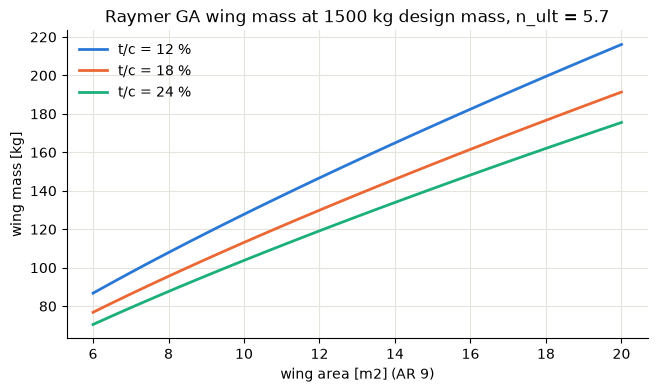

PASS  trend: thicker wing is lighter (t/c exponent -0.3)
PASS  trend: wing mass rises with area


In [7]:
# Trends: wing mass against area and thickness at fixed design mass.
area_m2 = np.linspace(6, 20, 50)
fig, ax = plt.subplots(figsize=(7.5, 4))
for airfoil_name, color in (("naca4412", blue), ("naca4418", orange), ("naca4424", aqua)):
    mass_kg = [float(Wing(area_m2=a, airfoil=asb.Airfoil(airfoil_name)).get_mass_properties(condition).mass)
               for a in area_m2]
    ax.plot(area_m2, mass_kg, color=color, lw=2, label=f"t/c = {airfoil_name[-2:]} %")
ax.set(xlabel="wing area [m2] (AR 9)", ylabel="wing mass [kg]",
       title="Raymer GA wing mass at 1500 kg design mass, n_ult = 5.7")
ax.legend(frameon=False)
plt.show()
thin = float(Wing(airfoil=asb.Airfoil("naca4412")).get_mass_properties(condition).mass)
thick = float(Wing(airfoil=asb.Airfoil("naca4424")).get_mass_properties(condition).mass)
check("trend: thicker wing is lighter (t/c exponent -0.3)", thick < thin)
check("trend: wing mass rises with area",
      float(Wing(area_m2=16).get_mass_properties(condition).mass) > float(Wing().get_mass_properties(condition).mass))

### 3. Assembly: mass and CG aggregation

`Aircraft.get_mass_breakdown` returns one `asb.MassProperties` per physical item;
`total()` is AeroSandbox addition, i.e. mass-weighted CG. The powertrain
installation sums `count x component.get_mass()` per located topology instance
times an installation factor (1.1 in the reference). Items are point masses: no
inertia tensor at this tier.

In [8]:
aircraft = build_reference_aircraft()
breakdown = aircraft.get_mass_breakdown(condition)
items = {f.name: getattr(breakdown, f.name) for f in fields(MassBreakdown)}
total = breakdown.total()
mass_kg = sum(float(i.mass) for i in items.values())
x_cg_m = sum(float(i.mass) * float(i.x_cg) for i in items.values()) / mass_kg
check("aggregation: total mass = sum of items", close(float(total.mass), mass_kg))
check("aggregation: x_cg = mass-weighted mean", close(float(total.x_cg), x_cg_m))
check("aggregation: empty mass = total - payload", close(float(breakdown.mass_empty_kg()), mass_kg - 300.0))

topology = aircraft.powertrain.topology
expected_powertrain_kg = 1.1 * sum(i.count * i.component.get_mass() for i in topology.instances.values())
for installed in aircraft.powertrain.get_instance_mass_properties():
    instance = topology.instances[installed.instance_name]
    print(f"{installed.instance_name:<11} x{instance.count}  {float(installed.mass_properties.mass):7.1f} kg  "
          f"at x = {float(installed.mass_properties.x_cg):.2f} m")
check("powertrain: installed mass = 1.1 x sum(count x get_mass())",
      close(float(breakdown.powertrain.mass), float(expected_powertrain_kg)))

shifted = replace(aircraft, payload=replace(aircraft.payload, x_m=4.0))
delta_m = float(shifted.get_cg_x_m(condition)) - float(total.x_cg)
check("aggregation: moving 300 kg payload 1 m aft shifts CG by 300 / m_total",
      close(delta_m, 300.0 / float(total.mass)))
try:
    replace(aircraft.powertrain, locations=aircraft.powertrain.locations[:-1])
    rejected = False
except ValueError as error:
    rejected = True
    print(f"    ValueError: {error}")
check("powertrain: unlocated instance rejected at construction", rejected)

PASS  aggregation: total mass = sum of items
PASS  aggregation: x_cg = mass-weighted mean
PASS  aggregation: empty mass = total - payload
turboshaft  x1    330.0 kg  at x = 4.60 m
generator   x1    110.0 kg  at x = 4.10 m
battery     x1    176.0 kg  at x = 2.60 m
motor       x4     88.0 kg  at x = 2.79 m
gearbox     x4     44.0 kg  at x = 2.79 m
propulsor   x4    132.0 kg  at x = 2.79 m
PASS  powertrain: installed mass = 1.1 x sum(count x get_mass())


PASS  aggregation: moving 300 kg payload 1 m aft shifts CG by 300 / m_total
    ValueError: Locations must cover every instance exactly; missing ['propulsor'], unknown [].
PASS  powertrain: unlocated instance rejected at construction


## 3. Tiltrotor weight models against the XV-15

*From `tier10_xv15_reference/xv15_mass_validation.ipynb`.*

In [9]:
import sys
from dataclasses import fields, replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.weights import afdd
from examples.xv15_reference import (Xv15GroupMasses, Xv15MassFactors, Xv15Reference, calibration_factors,
                                     compare_groups, mass_turboshaft_from_power_kg, published_groups,
                                     solve_xv15_closure)

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})
reference = Xv15Reference()

### 1. AFDD equations: identities and exponents

Each wrapper converts SI to the published units (lb, ft, ft/s, hp, rpm), then
evaluates the NDARC equation unchanged. Two checks follow. First, each wrapper
must match the equation written out in English units. Second, scaling one input
must scale the result by the published exponent.

In [10]:
rotor = dict(count_rotors=2, count_blades=3, radius_m=12.5 * u.foot, chord_m=14 * u.inch,
             speed_tip_m_s=740 * u.foot, frequency_flap_per_rev=1.55)
blades_lb = 0.02606 * 2 * 3**0.6592 * 12.5**1.3371 * (14 / 12)**0.9959 * 740**0.6682 * 1.55**2.5279
hub_lb = 0.003722 * 2 * 3**0.2807 * 12.5**1.5377 * 740**0.4290 * 1.55**2.1414 * (blades_lb / 2)**0.5505
gearbox_lb = 57.72 * 3100**0.8195 * 60**0.0680 * 3**0.0663 * 20**0.0369 / 565**0.6379
check("AFDD82 blades equal the English-unit equation",
      close(afdd.mass_blades_afdd82_kg(**rotor) / u.lbm, blades_lb))
check("AFDD82 hub equals the English-unit equation",
      close(afdd.mass_hub_afdd82_kg(2, 3, 12.5 * u.foot, 740 * u.foot, 1.55, blades_lb * u.lbm) / u.lbm, hub_lb))
check("AFDD83 gearbox and rotor shaft equal the English-unit equation",
      close(afdd.mass_gearbox_rotor_shaft_afdd83_kg(3100 * u.hp, 565 * u.rpm, 20000 * u.rpm, 3, 0.6) / u.lbm, gearbox_lb))
base = afdd.mass_blades_afdd82_kg(**rotor)
for name, exponent in (("radius_m", 1.3371), ("frequency_flap_per_rev", 2.5279)):
    check(f"blade mass scales as {name}^{exponent}",
          close(afdd.mass_blades_afdd82_kg(**{**rotor, name: 2 * rotor[name]}) / base, 2**exponent))

PASS  AFDD82 blades equal the English-unit equation
PASS  AFDD82 hub equals the English-unit equation
PASS  AFDD83 gearbox and rotor shaft equal the English-unit equation
PASS  blade mass scales as radius_m^1.3371
PASS  blade mass scales as frequency_flap_per_rev^2.5279


### 2. Engine mass from AeroSandbox's turboshaft regression

`power_turboshaft(mass)` fits historical turboshafts. It is inverted with one
explicit Opti equality at the LTC1K-4K take-off rating (1,550 shp). For
comparison, the T53-L-701 weighs 688 lb dry including its nose gearbox, which
the LTC1K-4K does not have.

In [11]:
mass_engine_kg = mass_turboshaft_from_power_kg(reference.power_takeoff_engine_W)
print(f"engine: {mass_engine_kg:.1f} kg = {mass_engine_kg / u.lbm:.0f} lb, "
      f"{reference.power_takeoff_engine_W / mass_engine_kg / 1e3:.2f} kW/kg")
check("engine mass between 450 lb and the 688 lb T53-L-701 bracket", 450 < mass_engine_kg / u.lbm < 688)
check("Tier 1 default specific power (2 kW/kg) is pessimistic at this size",
      reference.power_takeoff_engine_W / mass_engine_kg > 2000.0)

engine: 252.3 kg = 556 lb, 4.58 kW/kg
PASS  engine mass between 450 lb and the 688 lb T53-L-701 bracket
PASS  Tier 1 default specific power (2 kW/kg) is pessimistic at this size


### 3. Group by group at 13,000 lb

The aircraft is built from framework components at the published geometry. It
is then evaluated at the 13,000 lb design gross weight, using a 4.5 ultimate
load factor (limit 3.0, factor of safety 1.5) and a 200 kt cruise at
20,000 ft. The table maps the framework's breakdown onto the statement's
groups. Equipment (electrical, environmental, instrumentation, furnishings) is
carried at its published mass, so it is an input, not a prediction.

In [12]:
predicted = compare_groups(mass_engine_kg=mass_engine_kg)
labels = {"rotor": "rotor (AFDD82)", "wing": "wing (Raymer GA)", "tail": "tails (Raymer GA)",
          "fuselage": "fuselage (Raymer GA)", "alighting_gear": "landing gear (Raymer GA)",
          "flight_controls": "hydraulics + flight controls", "powerplant": "powerplant (ASB engine + AFDD82)",
          "transmission": "transmission (AFDD83 + AFDD82)", "equipment": "equipment (carried as given)"}
print(f"{'group':<34}{'predicted lb':>13}{'actual lb':>11}{'actual/pred':>13}")
for f in fields(Xv15GroupMasses):
    p, a = getattr(predicted, f.name), getattr(published_groups, f.name)
    print(f"{labels[f.name]:<34}{p / u.lbm:13.0f}{a / u.lbm:11.0f}{a / p:13.2f}")
print(f"{'basic empty weight':<34}{predicted.total() / u.lbm:13.0f}{published_groups.total() / u.lbm:11.0f}"
      f"{published_groups.total() / predicted.total():13.2f}")
check("published groups sum to the 9,076 lb basic empty weight", close(published_groups.total() / u.lbm, 9076))
check("drive system (AFDD83 + AFDD82) within 5 % of the transmission group",
      abs(predicted.transmission / published_groups.transmission - 1) < 0.05)
check("powerplant within 20 %", abs(predicted.powerplant / published_groups.powerplant - 1) < 0.20)

group                              predicted lb  actual lb  actual/pred
rotor (AFDD82)                             1545       1070         0.69
wing (Raymer GA)                            452        873         1.93
tails (Raymer GA)                           186        209         1.13
fuselage (Raymer GA)                        696       1442         2.07
landing gear (Raymer GA)                    585        508         0.87
hydraulics + flight controls                247        934         3.79
powerplant (ASB engine + AFDD82)           1532       1754         1.14
transmission (AFDD83 + AFDD82)             1265       1263         1.00
equipment (carried as given)               1023       1023         1.00
basic empty weight                         7530       9076         1.21
PASS  published groups sum to the 9,076 lb basic empty weight
PASS  drive system (AFDD83 + AFDD82) within 5 % of the transmission group
PASS  powerplant within 20 %


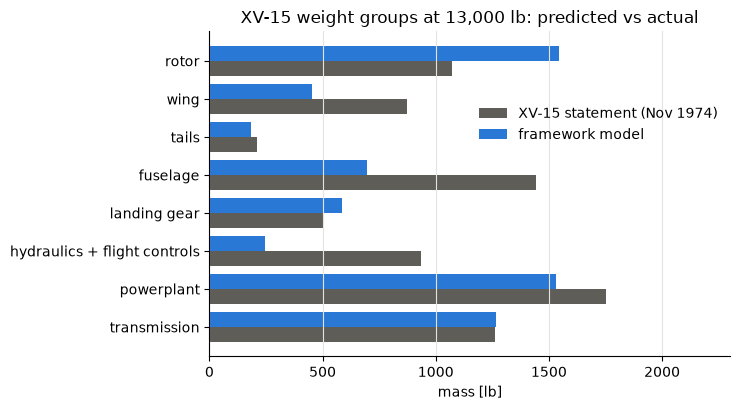

In [13]:
names = [f.name for f in fields(Xv15GroupMasses) if f.name != "equipment"]
y = np.arange(len(names))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(y + 0.2, [getattr(published_groups, n) / u.lbm for n in names], height=0.38, color=ink_muted,
        label="XV-15 statement (Nov 1974)")
ax.barh(y - 0.2, [getattr(predicted, n) / u.lbm for n in names], height=0.38, color=blue, label="framework model")
ax.set_yticks(y, [labels[n].split(" (")[0] for n in names])
ax.invert_yaxis()
ax.set(xlabel="mass [lb]", title="XV-15 weight groups at 13,000 lb: predicted vs actual")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 2300)
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(1.0, 0.62))
plt.tight_layout()
plt.show()

**Reading the comparison**

- **The rotorcraft-specific groups do well:**
  - The AFDD drive-system equations land within 1 % of the transmission group.
  - The engine section (the regression engine plus AFDD82 support, cowling and
    air induction) is within about 13 %.
- **The fixed-wing (Raymer GA) groups are the weak link.**
  - **Wing, about half of actual.** A tiltrotor wing is sized by torsional
    stiffness, to hold whirl-flutter margins against heavy wing-tip nacelles.
    It is thick (23 %), short and heavy, and Raymer's light-aircraft equation
    sees none of that.
  - **Fuselage, about half.** The XV-15 has crash load factors, ejection
    seats and a 13,000 lb class structure.
  - **Hydraulics and flight controls, about a quarter.** Raymer's fixed-wing
    controls omit the swashplates, rotor actuators, conversion actuators and
    redundant hydraulics.
- **The rotor depends on one uncertain input,** the coning frequency
  (section 5).

These factors are design-specific, and not all of them carry over to Halo.
The XV-15's research features add weight: ejection seats, crashworthy cells,
fail-safe redundant controls and an oxygen system (TM X-62407 sec. 3). An
unmanned aircraft would not carry them.

### 4. Calibration factors and closure

The calibration factor for each group is actual divided by predicted at design
weight. Two closures are solved on the XV-15's useful load (2,434 lb of crew,
research equipment, oil and payload plus 1,490 lb of fuel), keeping its
geometry and engines:

- **Uncalibrated:** what take-off weight does the framework predict for this
  aircraft?
- **Calibrated:** this must return exactly 13,000 lb. It's a consistency check
  that the factors are applied as a fixed point of the mass build-up.

In [14]:
factors = calibration_factors(mass_engine_kg=mass_engine_kg)
for f in fields(Xv15MassFactors):
    print(f"  {f.name:<17}{getattr(factors, f.name):6.2f}")
uncalibrated = solve_xv15_closure(mass_engine_kg=mass_engine_kg)
calibrated = solve_xv15_closure(factors=factors, mass_engine_kg=mass_engine_kg)
for label, r in (("uncalibrated", uncalibrated), ("calibrated", calibrated)):
    print(f"{label:>13}: take-off {r.mass_takeoff_kg / u.lbm:7,.0f} lb   empty {r.mass_empty_kg / u.lbm:6,.0f} lb   "
          f"residual {r.closure_residual_kg:.1e} kg")
check("calibrated closure returns 13,000 lb", close(calibrated.mass_takeoff_kg / u.lbm, 13000, rel=1e-6))
check("calibrated empty weight returns 9,076 lb", close(calibrated.mass_empty_kg / u.lbm, 9076, rel=1e-6))
check("uncalibrated framework closes light (empty weight under-predicted)",
      uncalibrated.mass_takeoff_kg < reference.mass_design_kg)

  rotor              0.69
  wing               1.93
  tail               1.13
  fuselage           2.07
  alighting_gear     0.87
  flight_controls    3.79
  powerplant         1.14
  transmission       1.00
  wing_tiltrotor     1.33


 uncalibrated: take-off  11,315 lb   empty  7,391 lb   residual -1.3e-11 kg
   calibrated: take-off  13,000 lb   empty  9,076 lb   residual 0.0e+00 kg
PASS  calibrated closure returns 13,000 lb
PASS  calibrated empty weight returns 9,076 lb
PASS  uncalibrated framework closes light (empty weight under-predicted)


### 5. Rotor mass and the coning frequency

NDARC uses the coning frequency for gimballed rotors. In TM X-62407 fig. 7.1.1,
the lowest collective mode sits at about 880 cpm at 565 rpm, roughly 1.55/rev,
but that value is read off a plot. Blade mass scales as nu^2.53 and hub mass
as nu^2.14, times a further blade-mass term. The published 1,070 lb rotor group
corresponds to nu of about 1.35, inside the range of the reading. Because the
rotor is sensitive to this input, plan 013 carries the calibrated rotor factor
rather than trusting nu.

coning frequency reproducing the 1,070 lb rotor group: 1.37/rev
PASS  rotor mass rises monotonically with coning frequency
PASS  published rotor group lies inside the 1.0-1.7/rev range


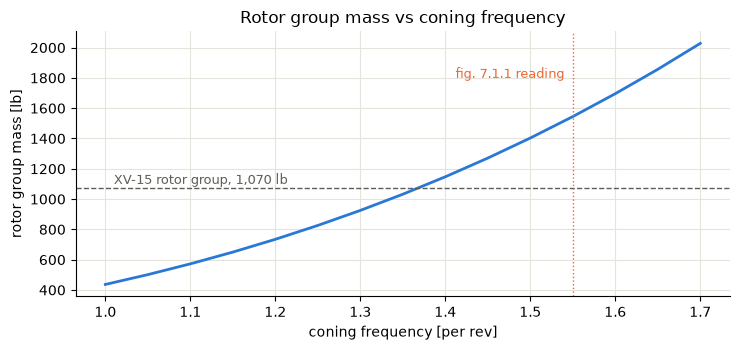

closed take-off weight over the same sweep [lb]: 10,101, 10,250, 10,428, 10,637, 10,880, 11,160, 11,480, 11,842


In [15]:
frequencies = np.linspace(1.0, 1.7, 15)
rotor_lb = [compare_groups(replace(reference, frequency_coning_per_rev=nu), mass_engine_kg=mass_engine_kg).rotor / u.lbm
            for nu in frequencies]
closed_lb = [solve_xv15_closure(replace(reference, frequency_coning_per_rev=nu),
                                mass_engine_kg=mass_engine_kg).mass_takeoff_kg / u.lbm for nu in frequencies]
nu_match = float(np.interp(published_groups.rotor / u.lbm, rotor_lb, frequencies))
print(f"coning frequency reproducing the 1,070 lb rotor group: {nu_match:.2f}/rev")
check("rotor mass rises monotonically with coning frequency", np.all(np.diff(rotor_lb) > 0))
check("published rotor group lies inside the 1.0-1.7/rev range", 1.0 < nu_match < 1.7)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(frequencies, rotor_lb, color=blue, lw=2, label="AFDD82 rotor group")
ax.axhline(published_groups.rotor / u.lbm, color=ink_muted, lw=1, ls="--")
ax.text(1.01, published_groups.rotor / u.lbm + 30, "XV-15 rotor group, 1,070 lb", color=ink_muted, fontsize=9)
ax.axvline(reference.frequency_coning_per_rev, color=orange, lw=1, ls=":")
ax.text(reference.frequency_coning_per_rev - 0.01, 1800, "fig. 7.1.1 reading", ha="right", color=orange, fontsize=9)
ax.set(xlabel="coning frequency [per rev]", ylabel="rotor group mass [lb]",
       title="Rotor group mass vs coning frequency")
plt.tight_layout()
plt.show()
print("closed take-off weight over the same sweep [lb]:", ", ".join(f"{m:,.0f}" for m in closed_lb[::2]))

## 4. The AFDD tiltrotor wing

*From `tier20_wing_weights/wing_weights_verification.ipynb`.*

In [16]:
import sys
from dataclasses import fields, replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.vehicle.condition import StructuralDesignCondition
from aircraft_closure.vehicle.surfaces import TiltrotorWingMassModel, Wing
from aircraft_closure.weights import afdd
from examples.tiltrotor_wing_calibration import (d266_rotor_implied_solidity, d266_wing_check, load_reference_data,
                                                 v22_wing_check, xv15_frequency_stiffness_ratios,
                                                 xv15_section_calibration)
from examples.xv15_reference import (Xv15MassFactors, Xv15Reference, build_xv15_aircraft, calibration_factors,
                                     compare_groups, design_condition, mass_turboshaft_from_power_kg, published_groups,
                                     solve_xv15_closure, xv15_wing_mass_model)
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, halo_equipment_items, solve_halo_sizing)

# Plan 026 made the AFDD wing and 900 kg the reference; this notebook keeps reproducing Tier 20 (Raymer wing as the
# default it compares against, 780 kg).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, HaloRequirements as _HaloRequirements
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          wing_weight_model="raymer", aerodynamics_model="simple", thermal_model=False)
HaloRequirements = partial(_HaloRequirements, mass_payload_kg=780.0)

# Current defaults (780 kg payload, equivalent-circuit battery, Raymer wing) plus the Tier 20 flag.
assumptions_raymer = HaloAssumptions()
assumptions_afdd = HaloAssumptions(wing_weight_model="afdd_tiltrotor")

check_log = globals().get("check_log", [])


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
ramp = ["#0d366b", "#184f95", "#256abf", "#3987e5", "#6da7ec", "#9ec5f4"]   # ordinal (blue 700 -> 200)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})
data = load_reference_data()
reference = Xv15Reference()
mass_engine_kg = mass_turboshaft_from_power_kg(reference.power_takeoff_engine_W)
factors = calibration_factors(mass_engine_kg=mass_engine_kg)

### 1. XV-15 section calibration

The published XV-15 stiffness (GJ, EI beam, EI chord), materials (aluminium) and component weights fix NDARC's
section constants. The torque-box chord ratio is not published; 0.45 is assumed. NDARC's torque-box area for
the published GJ, against the 567 lb box, gives the structural efficiency e_tb. The spar-cap area for the
published EI, against the 52 lb of spars, gives the taper correction C_t. These are the
`TiltrotorWingMassModel` defaults.

In [17]:
calibration = xv15_section_calibration()
defaults = TiltrotorWingMassModel(mass_tip_kg=1.0, radius_gyration_pylon_m=1.0, speed_rotor_design_rad_s=1.0,
                                  width_fuselage_m=1.0)
for f in fields(calibration):
    print(f"{f.name:<36}{getattr(calibration, f.name):10.4f}   default {getattr(defaults, f.name):10.4f}")
check("model defaults equal the XV-15 section calibration (0.5 %)",
      all(abs(getattr(defaults, f.name) / getattr(calibration, f.name) - 1) < 0.005 for f in fields(calibration)))
sensitivity = {w: xv15_section_calibration(w) for w in (0.35, 0.40, 0.45, 0.50, 0.55)}
for w, c in sensitivity.items():
    print(f"torque-box chord ratio {w:.2f}: e_tb {c.efficiency_torque_box:.3f}, C_t {c.correction_spar_stiffness:.3f}")

efficiency_torque_box                   0.5826   default     0.5830
correction_spar_stiffness               0.5262   default     0.5260
unit_mass_fairing_kg_m2                10.9248   default    10.9200
unit_mass_control_surfaces_kg_m2       15.1793   default    15.1800
fraction_fittings                       0.1290   default     0.1290
fraction_area_control_surfaces          0.1846   default     0.1850
PASS  model defaults equal the XV-15 section calibration (0.5 %)
torque-box chord ratio 0.35: e_tb 0.707, C_t 0.360
torque-box chord ratio 0.40: e_tb 0.635, C_t 0.531
torque-box chord ratio 0.45: e_tb 0.583, C_t 0.526
torque-box chord ratio 0.50: e_tb 0.544, C_t 0.506
torque-box chord ratio 0.55: e_tb 0.515, C_t 0.482


### 2. Frequencies to stiffness, and the XV-15 wing group

Next the model is driven the way it is used in sizing: by frequencies. The XV-15 published symmetric modes at
its 458 rpm airplane-mode rotor speed are torsion 8.3 Hz (1.09/rev), beam 3.3 Hz (0.43/rev) and chord 6.3 Hz
(0.83/rev). The tip mass, 2,142 lb per side, and the pylon radius of gyration, 2.77 ft (0.222 R), come from
the NASTRAN stick model. NDARC's single-mode relations then give about 0.6 of the published stiffness. That is
the model-form error of a reduced-order wing, so the wing is lighter than the statement.
`Xv15MassFactors.wing_tiltrotor` = 873 lb / model carries the difference. It is a separate factor; the Raymer
`wing` factor (1.93) is unchanged.

model / published stiffness (torsion, beam, chord): 0.574, 0.585, 0.623
PASS  frequency-driven stiffness within 0.5-0.7 of published (regression band)
XV-15 AFDD wing (x1): 658 lb; statement 873 lb; Acree breakdown 946 lb
factors: wing (Raymer) 1.930, wing_tiltrotor 1.327
PASS  wing_tiltrotor factor 1.33 +- 0.01
PASS  Raymer wing factor unchanged (1.93)
PASS  calibrated AFDD-wing XV-15 reproduces the statement


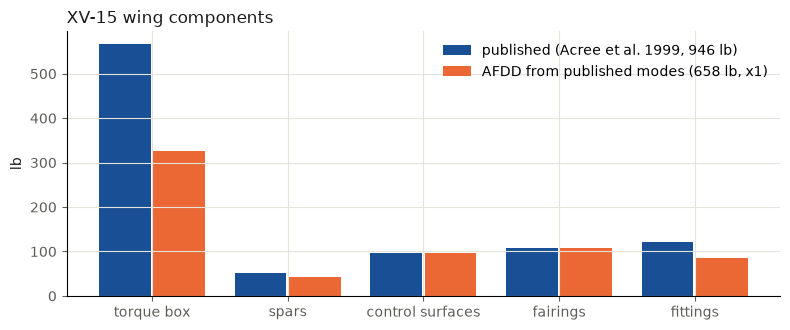

In [18]:
ratios = xv15_frequency_stiffness_ratios()
print("model / published stiffness (torsion, beam, chord):", ", ".join(f"{r:.3f}" for r in ratios))
check("frequency-driven stiffness within 0.5-0.7 of published (regression band)", all(0.5 < r < 0.7 for r in ratios))

wing = build_xv15_aircraft(reference, Xv15MassFactors(), mass_engine_kg, "afdd_tiltrotor").wing
xv15_masses = wing.mass_model.masses(wing, design_condition(reference.mass_design_kg, reference))
print(f"XV-15 AFDD wing (x1): {float(xv15_masses.total()) / u.lbm:.0f} lb; statement 873 lb; "
      f"Acree breakdown 946 lb")
print(f"factors: wing (Raymer) {factors.wing:.3f}, wing_tiltrotor {factors.wing_tiltrotor:.3f}")
check("wing_tiltrotor factor 1.33 +- 0.01", abs(factors.wing_tiltrotor - 1.327) < 0.01)
check("Raymer wing factor unchanged (1.93)", abs(factors.wing - 1.930) < 0.005)
groups = compare_groups(factors=factors, mass_engine_kg=mass_engine_kg, wing_weight_model="afdd_tiltrotor")
check("calibrated AFDD-wing XV-15 reproduces the statement", all(
    abs(getattr(groups, f.name) / getattr(published_groups, f.name) - 1) < 1e-6 for f in fields(groups)))

labels = ["torque box", "spars", "control surfaces", "fairings", "fittings"]
published = [567, 52, 97, 108, 122]
model = [xv15_masses.mass_torque_box_kg, xv15_masses.mass_spar_stiffness_kg + xv15_masses.mass_spar_jump_kg,
         xv15_masses.mass_control_surfaces_kg, xv15_masses.mass_fairing_kg, xv15_masses.mass_fittings_kg]
model = [float(m) / u.lbm for m in model]
fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(labels))
ax.bar(x - 0.2, published, 0.38, color=ramp[1], label="published (Acree et al. 1999, 946 lb)")
ax.bar(x + 0.2, model, 0.38, color=orange, label=f"AFDD from published modes ({sum(model):.0f} lb, x1)")
ax.set_xticks(x, labels)
ax.set_ylabel("lb")
ax.set_title("XV-15 wing components", color=ink, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 3. Identities, limits and trends

These spot checks come from the analytic tests (`tests/weights/test_tiltrotor_wing.py`):

- the box mass scales with the square of the torsion frequency;
- the wing gets heavier with span, design mass (through the jump take-off) and tip mass;
- with no bending requirement there are no stiffness caps;
- the realized torsion frequency equals the requirement.

PASS  wing mass rises with torsion frequency
PASS  wing mass rises with span (fixed chord)
PASS  wing mass does not fall with design mass (jump take-off)
PASS  box mass scales with torsion frequency squared
PASS  realized torsion frequency equals the requirement


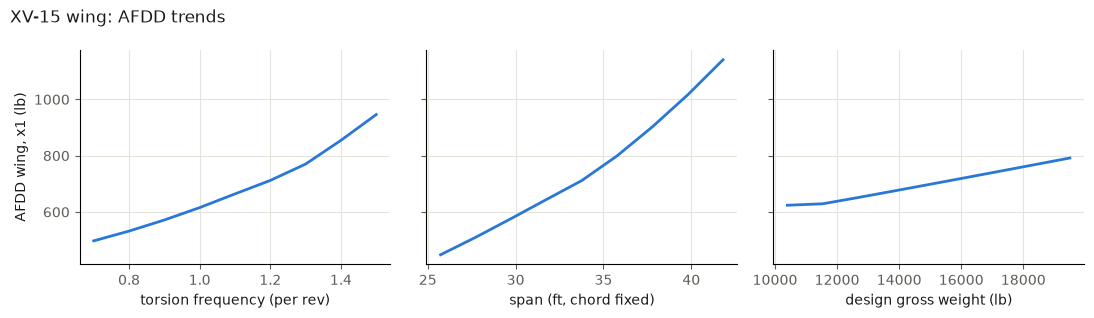

In [19]:
model = xv15_wing_mass_model(reference)
base_wing = Wing(area_m2=reference.area_wing_m2, aspect_ratio=reference.aspect_ratio_wing, mass_model=model)


def total_lb(model=model, wing=base_wing, mass_kg=reference.mass_design_kg):
    return float(model.mass_kg(wing, StructuralDesignCondition(mass_design_kg=mass_kg))) / u.lbm


frequencies = np.linspace(0.7, 1.5, 9)
spans = np.linspace(0.8, 1.3, 9)
design_masses = np.linspace(0.8, 1.5, 9)
by_frequency = [total_lb(replace(model, frequency_torsion_per_rev=f)) for f in frequencies]
by_span = [total_lb(wing=replace(base_wing, area_m2=reference.area_wing_m2 * s,
                                 aspect_ratio=reference.aspect_ratio_wing * s)) for s in spans]
by_design_mass = [total_lb(mass_kg=reference.mass_design_kg * m) for m in design_masses]
check("wing mass rises with torsion frequency", np.all(np.diff(by_frequency) > 0))
check("wing mass rises with span (fixed chord)", np.all(np.diff(by_span) > 0))
check("wing mass does not fall with design mass (jump take-off)", np.all(np.diff(by_design_mass) >= -1e-9))
condition = StructuralDesignCondition(mass_design_kg=reference.mass_design_kg)
box = lambda f: float(replace(model, frequency_torsion_per_rev=f).masses(base_wing, condition).mass_torque_box_kg)
check("box mass scales with torsion frequency squared", abs(box(2.0) / box(1.0) - 4.0) < 1e-9)
xm = model.masses(base_wing, condition)
check("realized torsion frequency equals the requirement",
      abs(float(xm.frequency_torsion_rad_s) / reference.speed_rotor_airplane_rad_s
          - reference.frequency_torsion_wing_per_rev) < 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, xs, ys, xlabel in ((axes[0], frequencies, by_frequency, "torsion frequency (per rev)"),
                           (axes[1], spans * reference.area_wing_m2**0.5 * reference.aspect_ratio_wing**0.5 / u.foot,
                            by_span, "span (ft, chord fixed)"),
                           (axes[2], design_masses * reference.mass_design_kg / u.lbm, by_design_mass,
                            "design gross weight (lb)")):
    ax.plot(xs, ys, color=blue, lw=2)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("AFDD wing, x1 (lb)")
fig.suptitle("XV-15 wing: AFDD trends", color=ink, x=0.01, ha="left")
plt.tight_layout()
plt.show()

### 4. Second calibration aircraft

The XV-15-calibrated model (section constants plus `wing_tiltrotor`) is applied with no further fitting:

- **V-22 FSD:**
  - graphite-epoxy material (Acree table 5), with the XV-15 frequency placement at its 333 rpm airplane-mode
    speed;
  - the tip mass is a framework model-chain estimate, because no public nacelle weights were found;
  - fold/rotate structure is excluded, because the source does not state the wing's scope.
- **Bell D266:**
  - aluminium, with the XV-15 placement at its 297 rpm maximum airplane-mode speed;
  - the tip mass is half the rotor and nacelle groups plus proprotor gearboxes;
  - t/c 0.23 and the fuselage width are assumed.

The rotor model is checked through the D266 rotor group. Its blade chord is not public, so the check reports
the solidity the XV-15-calibrated AFDD82 rotor needs to reach 2,439 lb.

aircraft               actual lb  model x1  x factor   error
XV-15 (calibration)          873       658       873   +0.0%
V-22 FSD                   2,470     1,524     2,023  -18.1%
Bell D266                  1,886     1,386     1,840   -2.4%
V-22 FSD: tip mass 6,482 lb per side; wing without fold/rotate; tip mass from the framework model chain
Bell D266: tip mass 2,117 lb per side; 1968 preliminary-design statement; t/c and fuselage width assumed
D266 rotor group 2,439 lb needs solidity 0.062 with AFDD82 x 0.69 (coning 1.55/rev)
PASS  V-22 wing: calibrated model within 25 % (under-predicts)
PASS  D266 wing: calibrated model within 10 %
PASS  D266 rotor implied solidity 0.062 (below the 0.08-0.11 of proprotors: the rotor model is heavy here)


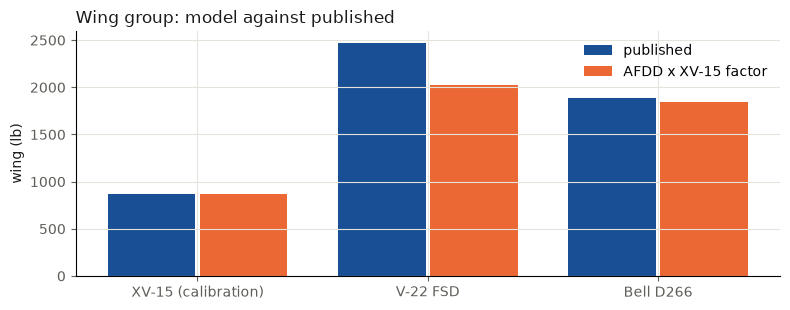

In [20]:
checks = [v22_wing_check(factors), d266_wing_check(factors)]
xv15_row = dict(aircraft="XV-15 (calibration)", actual=873.0, model=float(xv15_masses.total()) / u.lbm,
                calibrated=873.0)
rows = [xv15_row] + [dict(aircraft=c.aircraft, actual=c.mass_actual_kg / u.lbm, model=c.mass_predicted_kg / u.lbm,
                          calibrated=c.mass_predicted_calibrated_kg / u.lbm) for c in checks]
print(f"{'aircraft':<22}{'actual lb':>10}{'model x1':>10}{'x factor':>10}{'error':>8}")
for r in rows:
    print(f"{r['aircraft']:<22}{r['actual']:10,.0f}{r['model']:10,.0f}{r['calibrated']:10,.0f}"
          f"{r['calibrated'] / r['actual'] - 1:+8.1%}")
for c in checks:
    print(f"{c.aircraft}: tip mass {c.mass_tip_kg / u.lbm:,.0f} lb per side; {c.note}")
solidity = d266_rotor_implied_solidity(factors)
print(f"D266 rotor group 2,439 lb needs solidity {solidity:.3f} with AFDD82 x {factors.rotor:.2f} (coning 1.55/rev)")
check("V-22 wing: calibrated model within 25 % (under-predicts)", -0.25 < rows[1]["calibrated"] / rows[1]["actual"] - 1 < 0)
check("D266 wing: calibrated model within 10 %", abs(rows[2]["calibrated"] / rows[2]["actual"] - 1) < 0.10)
check("D266 rotor implied solidity 0.062 (below the 0.08-0.11 of proprotors: the rotor model is heavy here)",
      abs(solidity - 0.062) < 0.003)

fig, ax = plt.subplots(figsize=(8, 3.2))
x = np.arange(len(rows))
ax.bar(x - 0.2, [r["actual"] for r in rows], 0.38, color=ramp[1], label="published")
ax.bar(x + 0.2, [r["calibrated"] for r in rows], 0.38, color=orange, label="AFDD x XV-15 factor")
ax.set_xticks(x, [r["aircraft"] for r in rows])
ax.set_ylabel("wing (lb)")
ax.set_title("Wing group: model against published", color=ink, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 5. XV-15 closure with the AFDD wing

Tier 10a's uncalibrated closure with the Raymer wing gave 11,315 lb against the 13,000 lb design. The
stiffness-based wing is nearer the statement, so the uncalibrated closure moves up. Calibrated, both wing models
reproduce 13,000 lb.

In [21]:
closures = {(model_name, label): solve_xv15_closure(factors=f, mass_engine_kg=mass_engine_kg,
                                                    wing_weight_model=model_name)
            for model_name in ("raymer", "afdd_tiltrotor")
            for label, f in (("uncalibrated", Xv15MassFactors()), ("calibrated", factors))}
for (model_name, label), c in closures.items():
    print(f"{model_name:<15}{label:<14} take-off {c.mass_takeoff_kg / u.lbm:8,.0f} lb, empty {c.mass_empty_kg / u.lbm:7,.0f} lb,"
          f" wing {c.groups.wing / u.lbm:5,.0f} lb")
check("Raymer uncalibrated closure unchanged (11,315 lb)",
      abs(closures[("raymer", "uncalibrated")].mass_takeoff_kg / u.lbm - 11315) < 10)
check("AFDD calibrated closure 13,000 lb", abs(closures[("afdd_tiltrotor", "calibrated")].mass_takeoff_kg / u.lbm - 13000) < 1)
check("AFDD uncalibrated closure heavier than Raymer's",
      closures[("afdd_tiltrotor", "uncalibrated")].mass_takeoff_kg > closures[("raymer", "uncalibrated")].mass_takeoff_kg)

raymer         uncalibrated   take-off   11,315 lb, empty   7,391 lb, wing   423 lb
raymer         calibrated     take-off   13,000 lb, empty   9,076 lb, wing   873 lb
afdd_tiltrotor uncalibrated   take-off   11,536 lb, empty   7,612 lb, wing   629 lb
afdd_tiltrotor calibrated     take-off   13,000 lb, empty   9,076 lb, wing   873 lb
PASS  Raymer uncalibrated closure unchanged (11,315 lb)
PASS  AFDD calibrated closure 13,000 lb
PASS  AFDD uncalibrated closure heavier than Raymer's


### 7. Uncrewed adjustments, itemised

Until this tier the Halo equipment was one number: 587 lb, the XV-15 electrical, instrumentation and heating
groups, with heating relabelled as autonomy. It is now built from the XV-15 groups with explicit removals and
additions, and the total is unchanged. Crew items inside other groups are not split out, because there is no
public breakdown: cockpit controls sit in flight controls, and crew-station and crash structure in the fuselage.
They stay inside those calibration factors.

In [22]:
for item in halo_equipment_items:
    print(f"{item.mass_kg / u.lbm:+8.0f} lb  {item.label}  [{item.source}]")
total_lb = sum(i.mass_kg for i in halo_equipment_items) / u.lbm
print(f"{total_lb:8.0f} lb  total")
check("itemised equipment equals the previous 587 lb", abs(total_lb - 587) < 1e-9)
check("equipment default is the itemised total", abs(HaloAssumptions().mass_equipment_kg / u.lbm - total_lb) < 1e-9)

    +396 lb  electrical  [TM X-62407 sec. 3.1.2]
     +91 lb  instrumentation  [TM X-62407 sec. 3.1.2]
    +100 lb  heating and air conditioning  [TM X-62407 sec. 3.1.2]
    +436 lb  miscellaneous (furnishings, equipment)  [TM X-62407 sec. 3.1.2]
    -100 lb  remove crew environmental control (heating, ventilation, air conditioning)  [TM X-62407 sec. 3.1.2 (the ECS serves the crew station)]
    -230 lb  remove ejection seats  [Harris, NASA/SP-2015-215959 vol. III p. 312 (from the XV-15 weight statement)]
    -206 lb  remove other furnishings and miscellaneous crew equipment  [TM X-62407 sec. 3.1.2 miscellaneous less ejection seats]
    +100 lb  add autonomy and mission avionics (flight computers, sensors, datalinks)  [assumed allocation (the XV-15 carried 144 lb of avionics as useful load, not empty weight)]
     587 lb  total
PASS  itemised equipment equals the previous 587 lb
PASS  equipment default is the itemised total


## Summary

In [23]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} of {len(check_log)} checks passed")
for name in failed:
    print("FAILED:", name)

63 of 63 checks passed
